1. *Data Description*

Dataset Overview:

(1) The dataset consists of two related tables: a player dataset and a session dataset.

(2) The player dataset contains 196 unique players and 7 variables describing demographics and play history.

(3) The session dataset contains 1535 recorded play sessions and 5 variables detailing session start/end times


data collection method: the data is collected passively from a Minecraft server. `players.csv` contains registration and profile information provided by users upon signing up. `sessions.csv` is an automated log of player connection and disconnection times, generated by the server software.

dataset 1: player demographics and profile
| Variable     | Type        | Description                                       |
| ------------ | ----------- | ------------------------------------------------- |
| experience   | factor      | Self-reported experience level                    |
| subscribe    | logical     | Indicates whether player subscribed to newsletter |
| hashedEmail  | character   | Anonymous unique player ID                        |
| played_hours | double      | Total hours spent playing                         |
| name         | character   | Player display name                               |
| gender       | factor      | Reported gender                                   |
| Age          | integer     | Age in years                                      |

dataset 2: player session logs
| Variable Name           | Type                      | Meaning                                                                                                                                                             |
| ----------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **hashedEmail**         | character                    | A hashed (anonymized) unique identifier for each player. This is used to link sessions to the player dataset.                                                       |
| **start_time**          | character         | The recorded start time of the session, formatted as `DD/MM/YYYY HH:MM`. Requires conversion to a proper datetime type for analysis.                                |
| **end_time**            | character         | The recorded end time of the session, also formatted as `DD/MM/YYYY HH:MM`. Paired with `start_time` to compute session duration.                                   |
| **original_start_time** | double | Start time recorded as a Unix-like timestamp in scientific notation (e.g., `1.71977E+12`). This provides a more precise, timezone-standardized way to measure time. |
| **original_end_time**   | double | End time recorded in the same epoch timestamp format as `original_start_time`. Useful for precise duration calculations and time-series modeling.                   |


In [5]:
library(tidyverse)
library(repr)
library(tidymodels)
library(GGally)
library(ISLR)
options(repr.matrix.max.rows = 6)
options(scipen = 999)

*2. Questions*

Broad Question：

Question 3: We are interested in demand forecasting, namely, what time windows are most likely to have large number of simultaneous players. This is because we need to ensure that the number of licenses on hand is sufficiently large to accommodate all parallel players with high probability.


Specific Question：

“Can the total number of hours a player has accumulated (from players.csv) and the duration of their previous sessions (from sessions.csv) predict whether they will start a new session in the next 24 hours?”

Predictive method:

K-nearest neighbors classification (only one method)


How the data will help address the question：

To address this question, I will combine information from `players.csv` and `sessions.csv` using `hashedEmail`. From these data, I will create predictors such as a player’s total hours played and their average session duration. I will also compute a binary response variable that indicates whether a player begins another session within 24 hours of their most recent one. Using tidyverse tools like `mutate`, `summarize`, and `group_by`, I will construct a tidy dataset, which will then be used to train a K-nearest neighbors classification model to predict whether a player will return within 24 hours.

hashedEmail,start_time,end_time
<chr>,<dttm>,<dttm>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,2024-06-30 18:12:00,2024-06-30 18:24:00
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,2024-06-17 23:33:00,2024-06-17 23:46:00
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,2024-07-25 17:34:00,2024-07-25 17:57:00
⋮,⋮,⋮
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,2024-07-28 15:36:00,2024-07-28 15:57:00
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,2024-07-25 06:15:00,2024-07-25 06:22:00
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,2024-05-20 02:26:00,2024-05-20 02:45:00


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


Warning message:
“There was 1 warning in `summarize()`.
ℹ In argument: `across(everything(), mean, na.rm = TRUE)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


played_hours,Age
<dbl>,<dbl>
5.845918,21.13918


Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


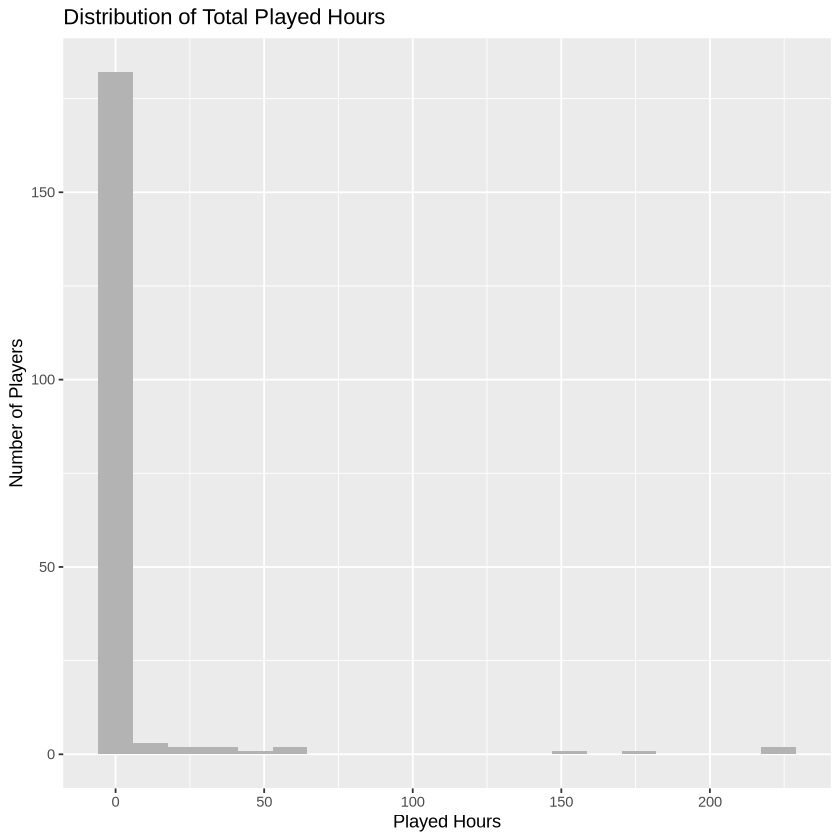

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


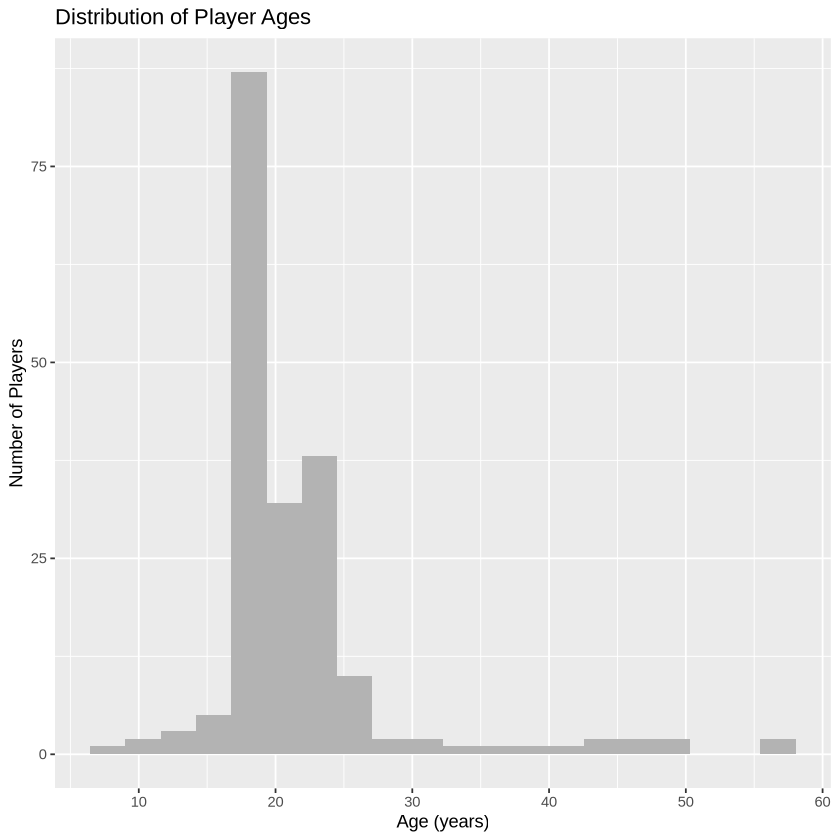

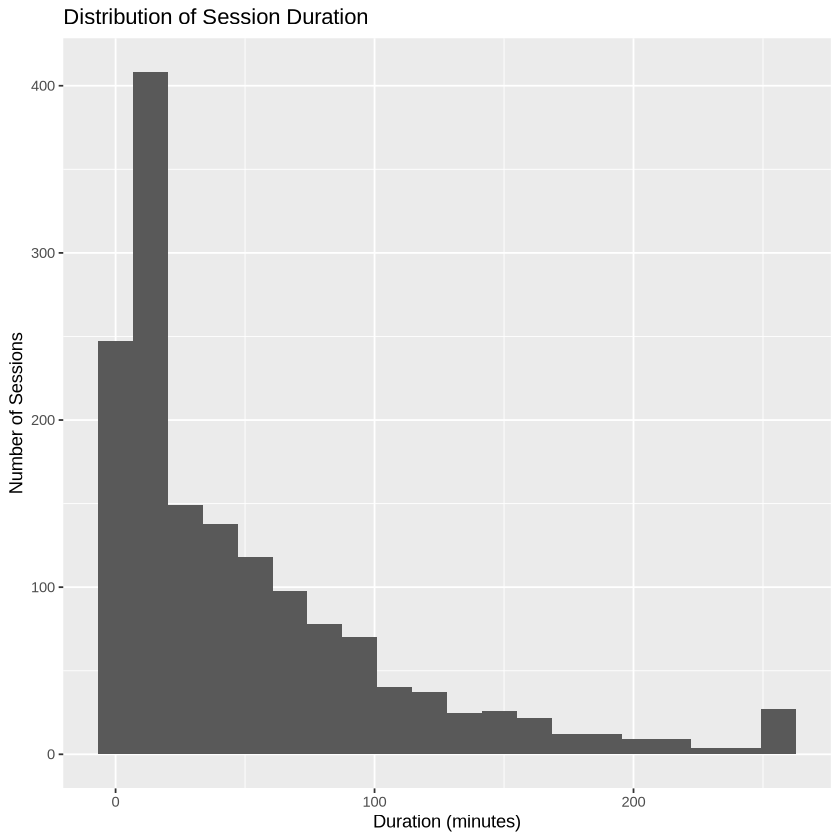

In [6]:
players <- read.csv("players.csv")
sessions <- read.csv("sessions.csv")

sessions <- sessions |>
  mutate(
    start_time = as.POSIXct(start_time, format = "%d/%m/%Y %H:%M"),
    end_time   = as.POSIXct(end_time, format = "%d/%m/%Y %H:%M")
  ) |>
  select(-original_start_time, -original_end_time)
sessions
players

players_means <- players |>
  select(where(is.numeric)) |>
  summarize(across(everything(), mean, na.rm = TRUE))

players_means

played_hours_plot <- players |>
  ggplot(aes(x = played_hours)) +
  geom_histogram(bins = 20, fill = "grey70") +
  labs(
    title = "Distribution of Total Played Hours",
    x = "Played Hours",
    y = "Number of Players"
  )
played_hours_plot

age_plot <- players |>
  ggplot(aes(x = Age)) +
  geom_histogram(bins = 20, fill = "grey70") +
  labs(
    title = "Distribution of Player Ages",
    x = "Age (years)",
    y = "Number of Players"
  )
age_plot

sessions <- sessions |>
  mutate(duration_minutes = as.numeric(difftime(end_time, start_time, units = "mins")))

session_plot <- sessions |>
  ggplot(aes(x = duration_minutes)) +
  geom_histogram(bins = 20) +
  labs(
    title = "Distribution of Session Duration",
    x = "Duration (minutes)",
    y = "Number of Sessions"
  )
session_plot

Overall insights:

Played hours are heavily skewed, indicating large differences in engagement that may require scaling later.

Age distribution is concentrated in younger users, especially those around 20, which might influence return behavior.

The histogram of session duration shows that most sessions are short, with a long right tail indicating a small number of much longer sessions, suggesting substantial variability in how long players stay in the game.